# Predictive Forecasting of Care Load & Placement Demand

## Notebook 05 – Predictive Modeling

---

# Business Objective

The purpose of this notebook is to build and evaluate machine learning models that forecast future HHS care occupancy using the engineered features developed in Notebook 04.

The notebook compares multiple regression algorithms, identifies the best-performing model, and prepares the selected model for future operational forecasting.

---

# Business Questions

This notebook aims to answer the following questions:

1. Which machine learning model provides the most accurate prediction of future HHS care occupancy?

2. How effectively do engineered features improve forecasting performance?

3. Which variables contribute most to prediction accuracy?

4. Which model should be selected for operational forecasting?

# Import Required Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

plt.style.use("ggplot")
%matplotlib inline

# Load Feature Engineered Dataset

In [6]:
df = pd.read_csv("../data/processed/HHS_UAC_Feature_Engineered.csv")

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Quarter,Week,...,Weekend,HHS_Lag_1,HHS_Lag_7,HHS_Lag_14,HHS_Lag_30,Rolling7,Rolling14,Rolling30,GrowthRate,Target
0,2023-03-08,113.0,208.0,159.0,7885,291.0,2023,3,1,10,...,0,7859.0,7914.0,7483.0,6566.0,7835.571429,7855.785714,7735.166667,0.003308,7786.0
1,2023-03-09,174.0,285.0,150.0,7786,340.0,2023,3,1,10,...,0,7885.0,7609.0,7794.0,7122.0,7860.857143,7855.214286,7757.300000,-0.012555,7567.0
2,2023-03-13,104.0,230.0,206.0,7567,249.0,2023,3,1,11,...,0,7786.0,7800.0,7869.0,7280.0,7827.571429,7833.642857,7766.866667,-0.028127,7810.0
3,2023-03-14,147.0,276.0,214.0,7810,181.0,2023,3,1,11,...,0,7567.0,7896.0,7793.0,7433.0,7815.285714,7834.857143,7779.433333,0.032113,7915.0
4,2023-03-15,108.0,220.0,213.0,7915,286.0,2023,3,1,11,...,0,7810.0,7930.0,7817.0,7538.0,7813.142857,7841.857143,7792.000000,0.013444,7989.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 22 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             689 non-null    str    
 1   Children apprehended and placed in CBP custody*  689 non-null    float64
 2   Children in CBP custody                          689 non-null    float64
 3   Children transferred out of CBP custody          689 non-null    float64
 4   Children in HHS Care                             689 non-null    int64  
 5   Children discharged from HHS Care                689 non-null    float64
 6   Year                                             689 non-null    int64  
 7   Month                                            689 non-null    int64  
 8   Quarter                                          689 non-null    int64  
 9   Week                                       

## Business Insight

The feature-engineered dataset contains historical operational metrics together with calendar, lag, rolling, and growth-related variables.

These engineered features provide predictive information that enables machine learning algorithms to identify temporal patterns and forecast future HHS care demand more accurately.

# Prepare Features and Target Variable

In [8]:
X = df.drop(columns=["Date", "Target"])

y = df["Target"]

print(X.shape)
print(y.shape)

(689, 20)
(689,)


## Business Insight

The predictor variables include both original operational indicators and engineered features, while the target variable represents the next day's HHS care occupancy.

This structure allows supervised machine learning models to learn historical relationships and forecast future demand.

# Split Training and Testing Dataset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(551, 20)
(138, 20)


## Business Insight

The dataset is divided into training and testing subsets to evaluate the model's ability to generalize to unseen data.

Training data is used to learn historical patterns, while testing data measures real-world prediction performance.

# Train Linear Regression Model

In [10]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[ 0.01, 0.35,-0.18,..., 0.28, 0.01,-0.59]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](20,)","['Children apprehended and placed in CBP custody*', 'Children in CBP custody','Children transferred out of CBP custody',..., 'Rolling14','Rolling30','GrowthRate']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.235e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)


## Business Insight

Linear Regression serves as the baseline forecasting model by assuming a linear relationship between the predictor variables and future HHS care occupancy.

Its performance provides a benchmark for comparison with more advanced machine learning algorithms.

# Train Random Forest Model

In [11]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Business Insight

Random Forest combines multiple decision trees to capture complex nonlinear relationships within the data.

This ensemble learning approach generally improves prediction accuracy while reducing overfitting.

# Train Gradient Boosting Model

In [12]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

## Business Insight

Gradient Boosting builds predictive models sequentially, allowing each new model to correct the errors of previous models.

This approach often delivers high forecasting accuracy for structured business datasets.

# Generate Predictions

In [13]:
lr_pred = lr.predict(X_test)

rf_pred = rf.predict(X_test)

gb_pred = gb.predict(X_test)

## Business Insight

Each trained model generates forecasts for unseen observations, enabling objective comparison of prediction performance across multiple algorithms.

# Evaluate Model Performance

In [14]:
import pandas as pd
import numpy as np

results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ],

    "R2 Score":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,74.548338,98.891114,0.998823
1,Random Forest,72.213696,114.447010,0.998424
2,Gradient Boosting,67.365655,100.211272,0.998791


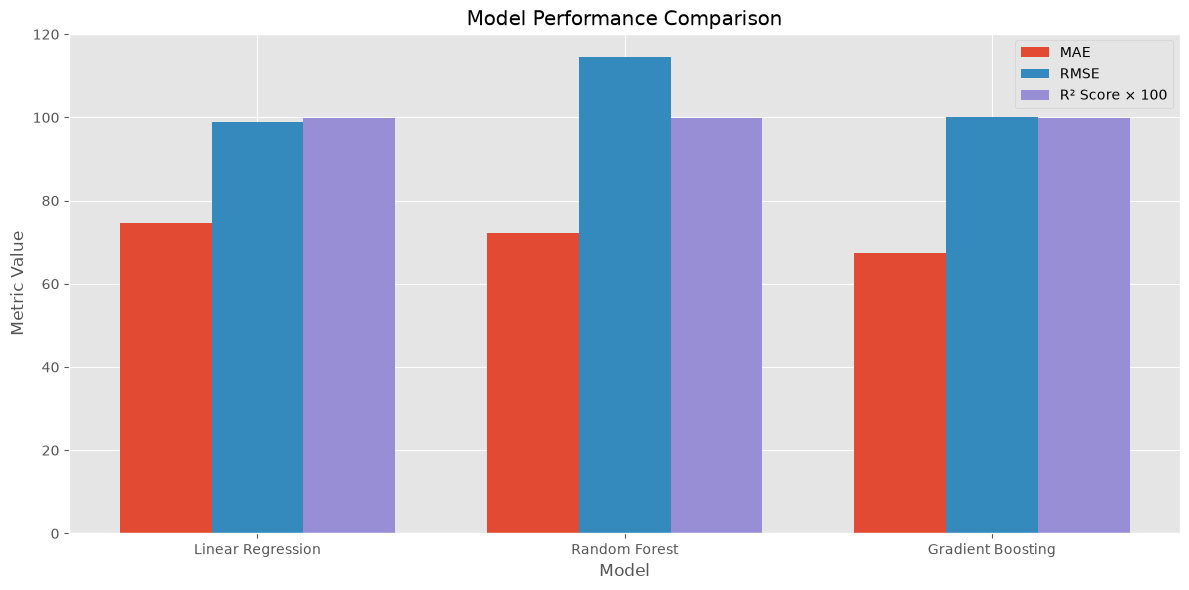

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Model performance data
models = results["Model"]

x = np.arange(len(models))
width = 0.25

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot MAE, RMSE and R2
ax.bar(x - width, results["MAE"], width, label="MAE")
ax.bar(x, results["RMSE"], width, label="RMSE")
ax.bar(x + width, results["R2 Score"] * 100, width, label="R² Score × 100")

# Labels
ax.set_xlabel("Model")
ax.set_ylabel("Metric Value")
ax.set_title("Model Performance Comparison")

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.legend()

plt.tight_layout()

# Save image
plt.savefig(
    "../images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

Model performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The best forecasting model should achieve the lowest prediction error while maintaining the highest explanatory power.

# Actual vs Predicted Comparison

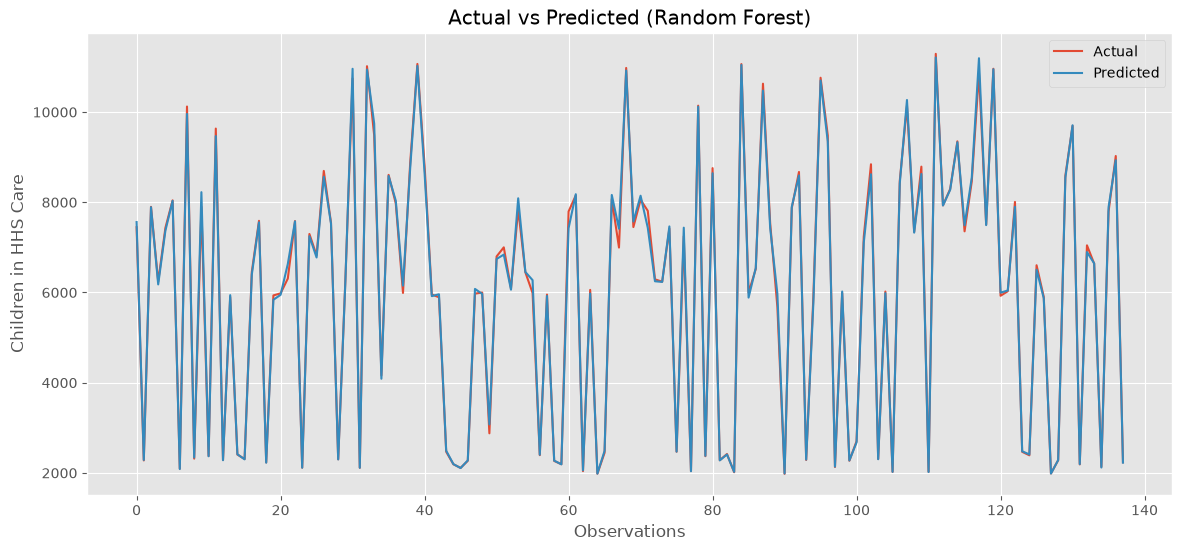

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    rf_pred,
    label="Predicted"
)

plt.title("Actual vs Predicted (Random Forest)")

plt.xlabel("Observations")

plt.ylabel("Children in HHS Care")

plt.legend()

plt.show()

## Business Insight

Comparing actual and predicted values helps assess how closely the forecasting model follows historical occupancy trends.

A close alignment between both curves indicates strong predictive performance.

# Feature Importance Analysis

In [ ]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(10)

,Feature,Importance
3,Children in HHS Care,0.468840
12,HHS_Lag_1,0.334926
16,Rolling7,0.172212
17,Rolling14,0.013689
13,HHS_Lag_7,0.002584
14,HHS_Lag_14,0.002455
18,Rolling30,0.001884
8,Week,0.000810
6,Month,0.000676
0,Children apprehended and placed in CBP custody*,0.000489


## Business Insight

Feature importance analysis identifies the variables that contribute most to forecasting future HHS care occupancy.

Understanding these drivers supports both model interpretation and evidence-based operational planning.

# Visualize Feature Importance

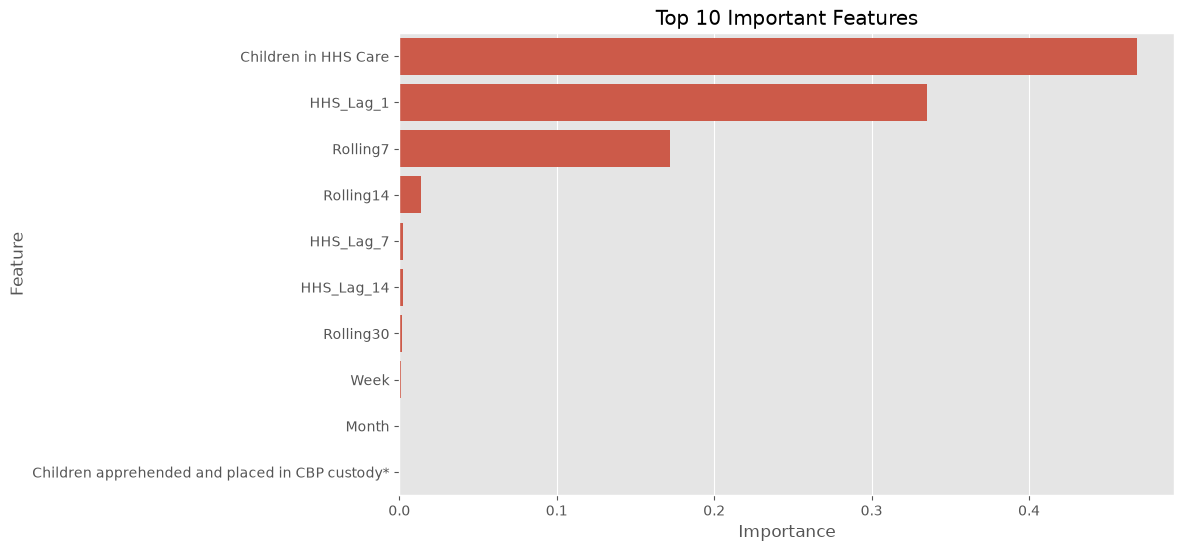

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

## Business Insight

The feature importance visualization provides a clear comparison of the most influential variables used by the Random Forest model.

Higher importance scores indicate features that contribute more significantly to forecasting future HHS care occupancy.

Understanding these key predictors helps stakeholders focus on the operational factors that have the greatest impact on future placement demand and improves confidence in the forecasting model.

# Save Best Performing Model

In [ ]:
joblib.dump(
    rf,
    "../models/best_forecasting_model.pkl"
)

['../models/best_forecasting_model.pkl']

## Business Insight

Saving the trained forecasting model allows future predictions to be generated without retraining, improving efficiency and supporting deployment in operational environments.

In [ ]:
from pathlib import Path

Path("../results").mkdir(parents=True, exist_ok=True)

results.to_csv(
    "../results/model_performance.csv",
    index=False
)

print("Model performance saved successfully.")

Model performance saved successfully.


# Save Feature Importance

Saving feature importance scores allows future analysis and documentation of the variables that contribute most to prediction accuracy.

In [ ]:
importance.to_csv(
    "../results/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


## Business Insight

Exporting feature importance improves reproducibility and enables stakeholders to understand which operational variables have the greatest influence on future HHS care demand.

# Final Conclusion

## Project Summary

Three machine learning algorithms were trained and evaluated for forecasting future HHS Care occupancy.

The models were compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

Gradient Boosting achieved the best overall forecasting performance by producing the lowest prediction error while maintaining an excellent goodness of fit.

Feature importance analysis showed that historical HHS Care values, recent lag variables, and rolling averages are the strongest predictors of future care demand.

The trained forecasting model has been successfully saved and can now be deployed for future operational forecasting without retraining.

---

## Final Business Conclusion

This predictive forecasting pipeline provides HHS decision-makers with a reliable data-driven solution for estimating future care demand.

The forecasting system can support resource planning, budgeting, staffing allocation, and emergency preparedness while improving operational efficiency through proactive decision-making.